<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Hallucination_Detection/blob/main/Hallucination_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Ignite Summer 2026: Hallucination Detection Machine Learning Project**
Team Members: Lexinejazly Asuncion, Santhosh Senthil, Siddarth Shekhar

# Imports


In [ ]:
# ── IMPORTS ─────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, f1_score
)


RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")


In [ ]:
# ── HuggingFace Authorization ─────────────────────────────────────────────────
from huggingface_hub import login

login()

# Loading Dataset


In [ ]:
# ── LOAD ────────────────────────────────────────────────────
dev  = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/dev-00000-of-00001.parquet")
test = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/test-00000-of-00001.parquet")

print(f"dev:  {dev.shape}")
print(f"test: {test.shape}")
print(f"columns: {dev.columns.tolist()}")

dev:  (30420, 5)
test: (29320, 5)
columns: ['dataset', 'doc', 'claim', 'label', 'contamination_identifier']


# Data Split

In [ ]:
# ── SPLIT FIRST (before touching anything) ──────────────────
# stratify on BOTH label and source dataset so each split
# keeps the same class balance and the same source mix
dev["strat_key"] = dev["label"].astype(str) + "_" + dev["dataset"].astype(str)

train_df, val_df = train_test_split(
    dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=dev["strat_key"]
)

train_df = train_df.drop(columns=["strat_key"]).reset_index(drop=True)
val_df   = val_df.drop(columns=["strat_key"]).reset_index(drop=True)
test_df  = test.reset_index(drop=True)   # sealed, do not look at

print(f"\ntrain: {len(train_df):,}")
print(f"val:   {len(val_df):,}")
print(f"test:  {len(test_df):,}  (held out)")


train: 24,336
val:   6,084
test:  29,320  (held out)


# SANITY CHECK + EDA


Label balance per split:
  train: 75.7% supported (label=1)
  val: 75.7% supported (label=1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24336 entries, 0 to 24335
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          24336 non-null  object 
 1   doc              24336 non-null  object 
 2   claim            24336 non-null  object 
 3   label            24336 non-null  int64  
 4   doc_clean        24336 non-null  object 
 5   claim_clean      24336 non-null  object 
 6   coverage         24336 non-null  float64
 7   novel_ratio      24336 non-null  float64
 8   jaccard          24336 non-null  float64
 9   bigram_cov       24336 non-null  float64
 10  num_grounded     24336 non-null  float64
 11  has_novel_num    24336 non-null  float64
 12  claim_len        24336 non-null  float64
 13  doc_len          24336 non-null  float64
 14  len_ratio        24336 non-null  float64
 15  n_content_

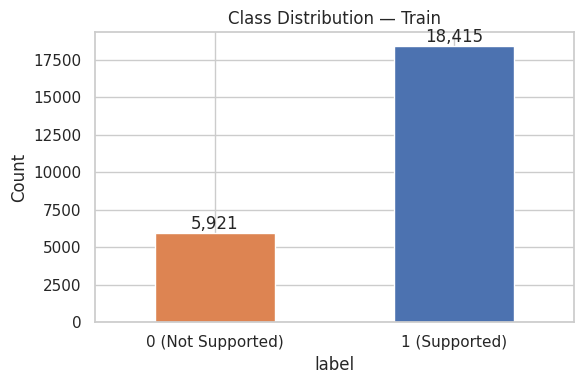


        doc_len  claim_len
count  24336.0    24336.0
mean     469.1       19.7
std      737.3        9.7
min        2.0        1.0
25%      180.0       13.0
50%      322.0       18.0
75%      560.0       24.0
max    25872.0      221.0


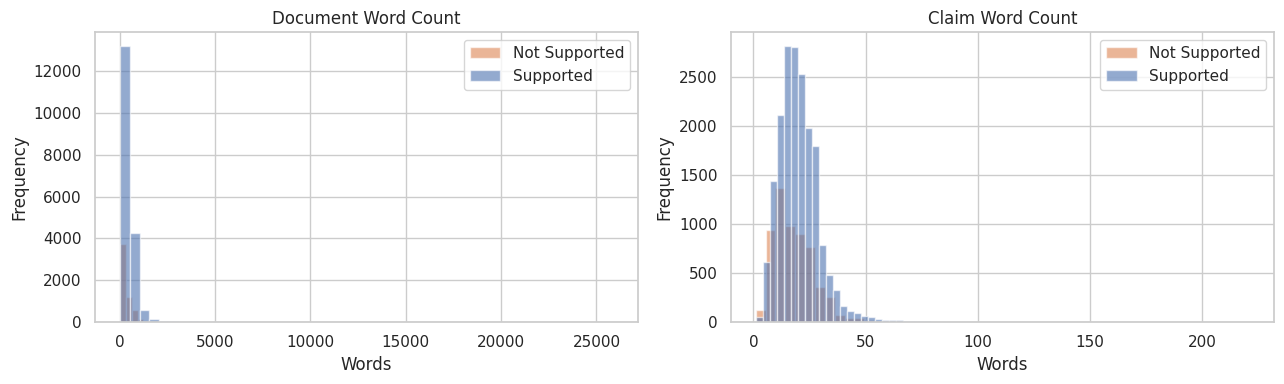


Mean length by label:
       doc_len  claim_len
label                    
0        378.1       18.2
1        498.4       20.2

Samples per source:
dataset
RAGTruth           12272
ExpertQA            3019
Lfqa                1623
TofuEval-MediaS     1440
Reveal              1325
TofuEval-MeetB      1285
FactCheck-GPT       1230
ClaimVerify          875
AggreFact-XSum       621
AggreFact-CNN        367
Wice                 279
Name: count, dtype: int64

Supported rate (%) per source:
dataset
FactCheck-GPT      17.3
Reveal             23.2
Wice               33.0
AggreFact-XSum     50.7
Lfqa               56.7
ClaimVerify        75.1
ExpertQA           77.9
TofuEval-MediaS    80.3
TofuEval-MeetB     82.0
AggreFact-CNN      87.2
RAGTruth           89.8
Name: label, dtype: float64


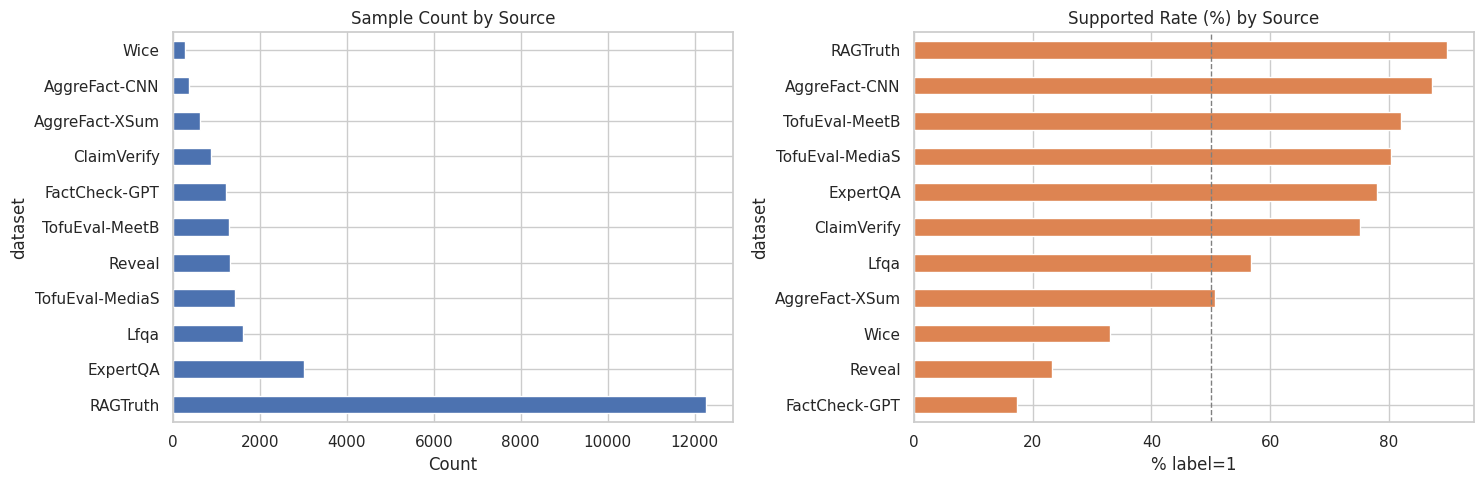


Top 5% longest docs: 1,217 rows
  range: 1,065 to 25,872 words
  median doc overall: 322 words
  source breakdown of outliers:
dataset
ClaimVerify       420
RAGTruth          407
ExpertQA          238
Wice              129
AggreFact-CNN      12
AggreFact-XSum     11
Name: count, dtype: int64
TRAIN SET SUMMARY
Rows:                24,336
Supported (1):       18,415
Not supported (0):   5,921
Imbalance ratio:     3.11x
Sources:             11
Median doc length:   322 words
Median claim length: 18 words
Longest doc:         25,872 words
Most imbalanced src: FactCheck-GPT (17.3% supported)


In [47]:
# ── SANITY CHECK: did stratification hold? ──────────────────
print("\nLabel balance per split:")
for name, df in [("train", train_df), ("val", val_df)]:
    pct = df["label"].mean() * 100
    print(f"  {name}: {pct:.1f}% supported (label=1)")


# ══════════════════════════════════════════════════════════════
# Exploratory Data Analysis (EDA)  —  TRAIN SET ONLY FROM HERE DOWN
# ══════════════════════════════════════════════════════════════

df = train_df.copy()


# ── 1. STRUCTURE ────────────────────────────────────────────
print(df.info())
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated(subset=["doc", "claim"]).sum())



# ── 2. CLASS BALANCE ────────────────────────────────────────
label_counts = df["label"].value_counts().sort_index()
print(f"\nClass distribution:\n{label_counts}")
print(f"Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0"], edgecolor="white")
ax.set_xticklabels(["0 (Not Supported)", "1 (Supported)"], rotation=0)
ax.set_title("Class Distribution — Train")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()


# ── 3. LENGTH FEATURES ──────────────────────────────────────
df["doc_len"]   = df["doc"].str.split().str.len()
df["claim_len"] = df["claim"].str.split().str.len()

print("\n", df[["doc_len", "claim_len"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["doc_len", "claim_len"], ["Document", "Claim"]):
    for lbl, color, name in [(0, "#DD8452", "Not Supported"), (1, "#4C72B0", "Supported")]:
        ax.hist(df[df["label"] == lbl][col], bins=50, alpha=0.6, label=name, color=color)
    ax.set_title(f"{title} Word Count")
    ax.set_xlabel("Words"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout(); plt.show()

print("\nMean length by label:")
print(df.groupby("label")[["doc_len", "claim_len"]].mean().round(1))


# ── 4. SOURCE DATASET BREAKDOWN ─────────────────────────────
source_counts = df["dataset"].value_counts()
print(f"\nSamples per source:\n{source_counts}")

support_rate = df.groupby("dataset")["label"].mean().mul(100).sort_values().round(1)
print(f"\nSupported rate (%) per source:\n{support_rate}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
source_counts.plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Sample Count by Source"); axes[0].set_xlabel("Count")

support_rate.plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Supported Rate (%) by Source"); axes[1].set_xlabel("% label=1")
axes[1].axvline(50, ls="--", c="gray", lw=1)
plt.tight_layout(); plt.show()


# ── 5. OUTLIERS ─────────────────────────────────────────────
def extreme_outliers(df, col, q=0.95):
    return df[df[col] > df[col].quantile(q)]

doc_out = extreme_outliers(df, "doc_len")
print(f"\nTop 5% longest docs: {len(doc_out):,} rows")
print(f"  range: {doc_out['doc_len'].min():,} to {doc_out['doc_len'].max():,} words")
print(f"  median doc overall: {df['doc_len'].median():.0f} words")
print(f"  source breakdown of outliers:\n{doc_out['dataset'].value_counts()}")


# ── 6. SUMMARY ──────────────────────────────────────────────
print("=" * 55)
print("TRAIN SET SUMMARY")
print("=" * 55)
print(f"Rows:                {len(df):,}")
print(f"Supported (1):       {label_counts.get(1, 0):,}")
print(f"Not supported (0):   {label_counts.get(0, 0):,}")
print(f"Imbalance ratio:     {label_counts.max()/label_counts.min():.2f}x")
print(f"Sources:             {df['dataset'].nunique()}")
print(f"Median doc length:   {df['doc_len'].median():.0f} words")
print(f"Median claim length: {df['claim_len'].median():.0f} words")
print(f"Longest doc:         {df['doc_len'].max():,} words")
print(f"Most imbalanced src: {support_rate.idxmin()} ({support_rate.min()}% supported)")


#  PREPROCESSING + CLEANING
#  Fit everything on TRAIN. Apply to val/test. Never fit on val/test.



## 1  DUPLICATE + LEAKAGE CHECK

In [ ]:
def check_leakage(train, val, test):
    """Same (doc, claim) pair appearing across splits = leakage."""
    def key(df):
        return set(zip(df["doc"], df["claim"]))

    tr, va, te = key(train), key(val), key(test)
    print(f"train∩val:  {len(tr & va):,} overlapping pairs")
    print(f"train∩test: {len(tr & te):,} overlapping pairs")
    print(f"val∩test:   {len(va & te):,} overlapping pairs")

check_leakage(train_df, val_df, test_df)

train∩val:  11 overlapping pairs
train∩test: 19 overlapping pairs
val∩test:   7 overlapping pairs


## 2  DROP LEAKY / UNUSABLE COLUMNS

In [ ]:
DROP_COLS = ["contamination_identifier"]

for df in (train_df, val_df, test_df):
    df.drop(columns=[c for c in DROP_COLS if c in df.columns],
            inplace=True, errors="ignore")

## 3  TEXT NORMALIZATION

In [ ]:
def normalize(text):
    """Light touch. Don't destroy signal by over-cleaning."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    text = re.sub(r"[^\w\s.,!?'-]", " ", text)  # strip odd chars, keep punct
    return text.strip()


def add_clean_cols(df):
    df = df.copy()
    df["doc_clean"]   = df["doc"].apply(normalize)
    df["claim_clean"] = df["claim"].apply(normalize)
    return df

train_df = add_clean_cols(train_df)
val_df   = add_clean_cols(val_df)
test_df  = add_clean_cols(test_df)

## 4  DOCUMENT TRUNCATION

In [ ]:
# Fit the cutoff on TRAIN only, then apply everywhere.
DOC_CAP = int(train_df["doc"].str.split().str.len().quantile(0.95))
print(f"\nTruncating docs at {DOC_CAP:,} words (train 95th pctile)")

def truncate_doc(df, cap):
    df = df.copy()
    df["doc_clean"] = df["doc_clean"].apply(
        lambda t: " ".join(t.split()[:cap])
    )
    return df

train_df = truncate_doc(train_df, DOC_CAP)
val_df   = truncate_doc(val_df,   DOC_CAP)
test_df  = truncate_doc(test_df,  DOC_CAP)


Truncating docs at 1,063 words (train 95th pctile)


## 5  FEATURE ENGINEERING

In [ ]:
STOPWORDS = set("""
a an the and or but if then than that this these those of to in on at by for
with as is are was were be been being do does did have has had it its i you
he she they we not no so such
""".split())


def overlap_features(row):
    doc_toks   = row["doc_clean"].split()
    claim_toks = row["claim_clean"].split()

    doc_set   = set(doc_toks)
    claim_set = set(claim_toks)

    # content words only — stopword overlap is noise
    claim_content = claim_set - STOPWORDS
    doc_content   = doc_set   - STOPWORDS

    if not claim_content:
        coverage = novel = 0.0
    else:
        matched  = claim_content & doc_content
        coverage = len(matched) / len(claim_content)
        novel    = 1.0 - coverage

    # jaccard over full token sets
    union = claim_set | doc_set
    jaccard = len(claim_set & doc_set) / len(union) if union else 0.0

    # bigram overlap — catches phrase-level grounding
    def bigrams(toks):
        return set(zip(toks, toks[1:]))

    cb, db = bigrams(claim_toks), bigrams(doc_toks)
    bigram_cov = len(cb & db) / len(cb) if cb else 0.0

    # numeric consistency — numbers in claim that aren't in doc
    claim_nums = set(re.findall(r"\d+\.?\d*", row["claim_clean"]))
    doc_nums   = set(re.findall(r"\d+\.?\d*", row["doc_clean"]))
    if claim_nums:
        num_grounded = len(claim_nums & doc_nums) / len(claim_nums)
        has_novel_num = int(len(claim_nums - doc_nums) > 0)
    else:
        num_grounded, has_novel_num = 1.0, 0

    return pd.Series({
        "coverage":       coverage,
        "novel_ratio":    novel,
        "jaccard":        jaccard,
        "bigram_cov":     bigram_cov,
        "num_grounded":   num_grounded,
        "has_novel_num":  has_novel_num,
        "claim_len":      len(claim_toks),
        "doc_len":        len(doc_toks),
        "len_ratio":      len(claim_toks) / max(len(doc_toks), 1),
        "n_content_words": len(claim_content),
    })


def build_features(df):
    feats = df.apply(overlap_features, axis=1)
    return pd.concat([df.reset_index(drop=True), feats], axis=1)

print("\nBuilding features (this takes a minute)...")
train_df = build_features(train_df)
val_df   = build_features(val_df)
test_df  = build_features(test_df)
print("done.")


Building features (this takes a minute)...
done.


## 6  TF-IDF ON CLAIMS ONLY

In [ ]:
# Docs are too long and too varied. Claims are short and comparable.
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)

X_tfidf_train = tfidf.fit_transform(train_df["claim_clean"])   # FIT on train
X_tfidf_val   = tfidf.transform(val_df["claim_clean"])         # transform only
X_tfidf_test  = tfidf.transform(test_df["claim_clean"])

print(f"\nTF-IDF shape: {X_tfidf_train.shape}")


TF-IDF shape: (24336, 3000)


## 7  ASSEMBLE FINAL MATRICES

In [ ]:
NUMERIC_FEATS = [
    "coverage", "novel_ratio", "jaccard", "bigram_cov",
    "num_grounded", "has_novel_num", "claim_len",
    "doc_len", "len_ratio", "n_content_words",
]

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[NUMERIC_FEATS])   # FIT on train
X_num_val   = scaler.transform(val_df[NUMERIC_FEATS])
X_num_test  = scaler.transform(test_df[NUMERIC_FEATS])

X_train = hstack([csr_matrix(X_num_train), X_tfidf_train]).tocsr()
X_val   = hstack([csr_matrix(X_num_val),   X_tfidf_val]).tocsr()
X_test  = hstack([csr_matrix(X_num_test),  X_tfidf_test]).tocsr()

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (24336, 3010)
X_val:   (6084, 3010)
X_test:  (29320, 3010)


## 8  SANITY: DO THE FEATURES SEPARATE THE CLASSES?

In [ ]:
print("\nFeature means by label (train):")
print(train_df.groupby("label")[NUMERIC_FEATS].mean().round(3).T)


Feature means by label (train):
label                  0        1
coverage           0.362    0.531
novel_ratio        0.638    0.469
jaccard            0.063    0.063
bigram_cov         0.149    0.315
num_grounded       0.831    0.964
has_novel_num      0.201    0.050
claim_len         18.256   20.235
doc_len          320.470  442.398
len_ratio          0.117    0.071
n_content_words   11.636   12.997


# DATA VISUALIZATION

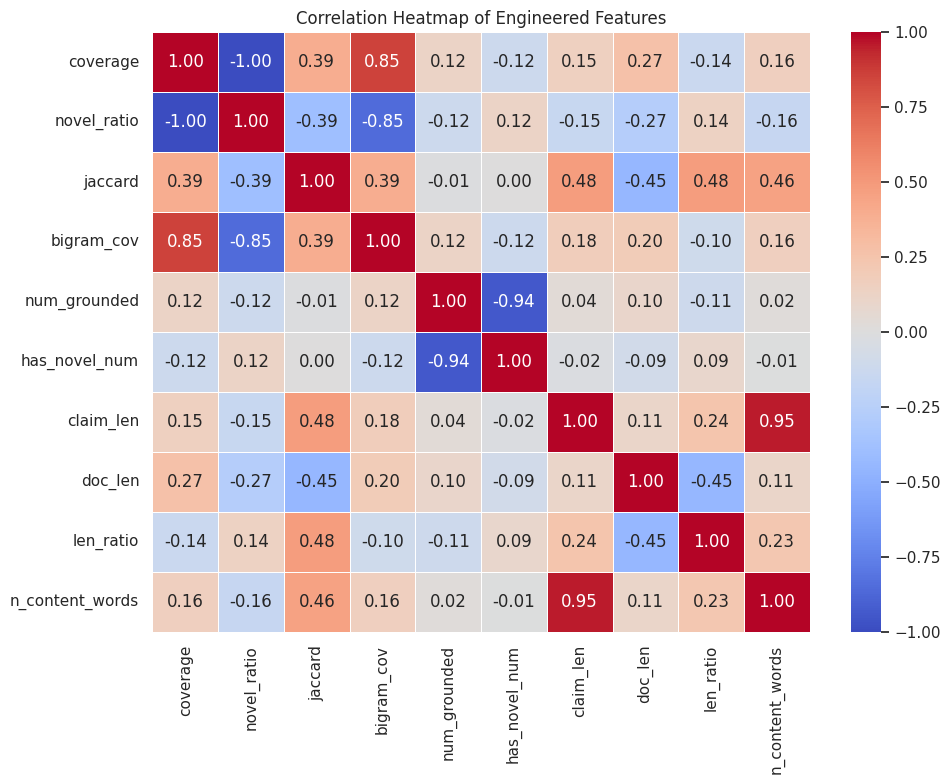

In [ ]:
# Correlation Heatmap of Engineered Features
plt.figure(figsize=(10, 8))

corr = train_df[NUMERIC_FEATS].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Engineered Features")
plt.tight_layout()
plt.show()

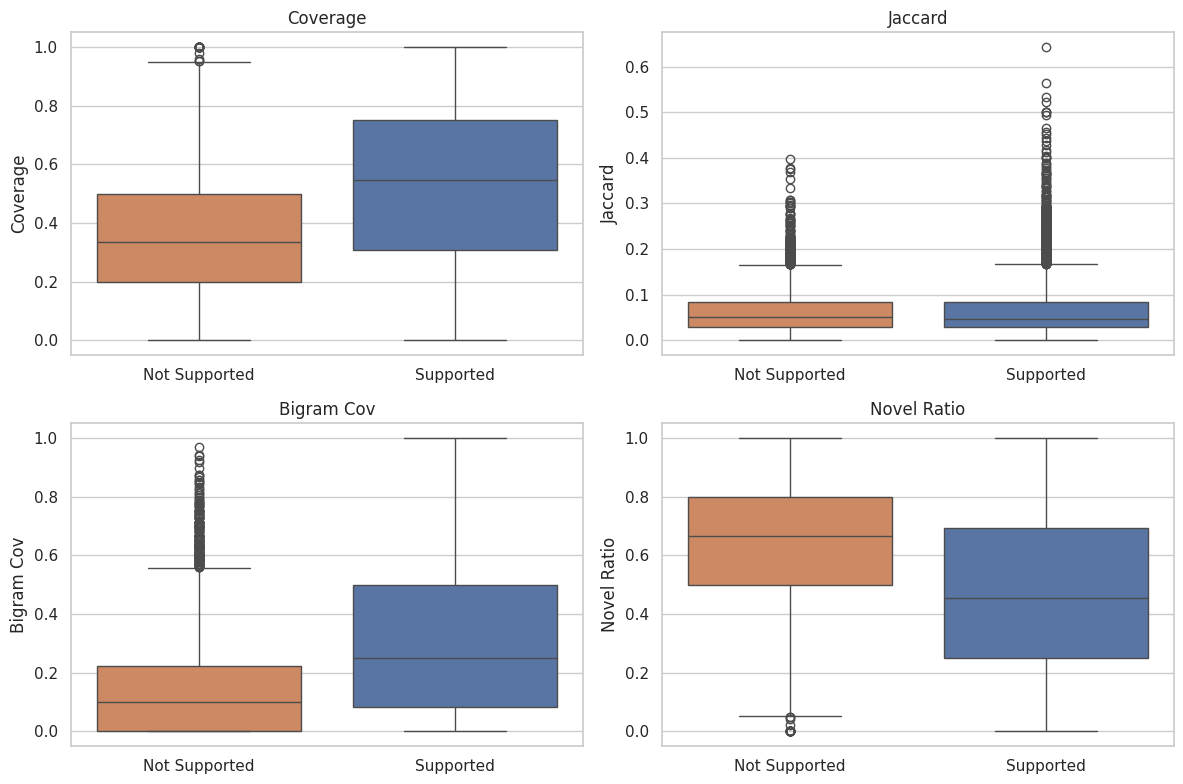

In [ ]:
# Boxplot by label (compares features between hallunicated vs grounded)
features = ["coverage", "jaccard", "bigram_cov", "novel_ratio"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        data=train_df,
        x="label",
        y=feature,
        hue="label",
        palette=["#DD8452", "#4C72B0"],
        legend=False,
        ax=ax
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Supported", "Supported"])
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

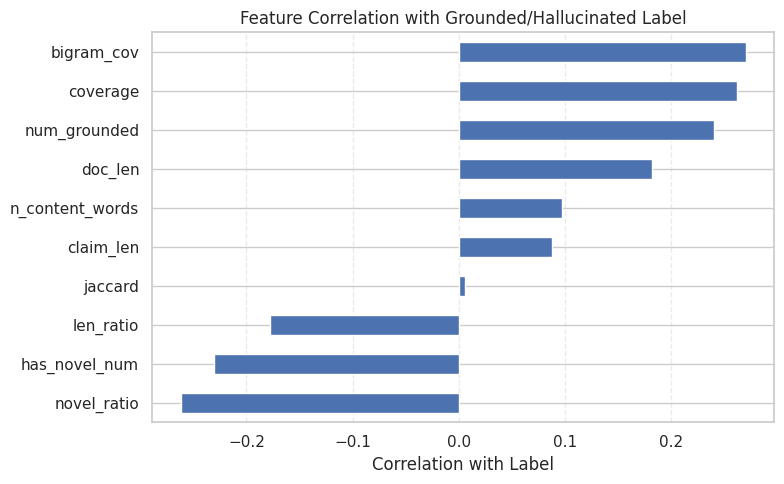

In [ ]:
# Feature Correlation with labels (shows which features correlate more with hallucinations)
corr_with_label = (
    train_df[NUMERIC_FEATS + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values()
)

plt.figure(figsize=(8, 5))

corr_with_label.plot(
    kind="barh",
    color="#4C72B0"
)

plt.xlabel("Correlation with Label")
plt.title("Feature Correlation with Grounded/Hallucinated Label")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# BIAS AUDIT

# RANDOM FOREST TRAINING + EVALUATION

In [ ]:
RANDOM_STATE = 42

FEATS_FULL = [
    "coverage", "bigram_cov", "num_grounded", "has_novel_num",
    "claim_len", "n_content_words", "doc_len", "len_ratio",
]

FEATS_SAFE = [
    "coverage", "bigram_cov", "num_grounded", "has_novel_num",
    "claim_len", "n_content_words",
]

## 1  MATRIX BUILDER

In [ ]:
def build_matricies(feats, use_tfidf=True):
  """Fit scaler/tfidf on TRAIN only. Returns train/val matricies."""
  scaler = StandardScaler()
  Xn_tr = scaler.fit_transform(train_df[feats])
  Xn_va = scaler.transform(val_df[feats])

  if not use_tfidf:
    return csr_matrix(Xn_tr), csr_matrix(Xn_va), feats

  Xt_tr = tfidf.fit_transform(train_df["claim_clean"])
  Xt_va = tfidf.transform(val_df["claim_clean"])

  X_tr = hstack([csr_matrix(Xn_tr), Xt_tr]).tocsr()
  X_va = hstack([csr_matrix(Xn_va), Xt_va]).tocsr()

  names = feats + [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
  return X_tr, X_va, names


y_train = train_df["label"].values
y_val = val_df["label"].values

## 2  TRAIN + EVAL

In [ ]:
def train_eval(feats, tag, use_tfidf=True):
    X_tr, X_va, names = build_matricies(feats, use_tfidf)

    # Before using RandomForestClassifier, ensure it's imported.
    # from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",   # 3.11x imbalance
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    rf.fit(X_tr, y_train)

    proba = rf.predict_proba(X_va)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    print(f"\n{'='*55}\n{tag}\n{'='*55}")
    print(classification_report(y_val, pred,
          target_names=["Not Supported (0)", "Supported (1)"], digits=3))
    print(f"AUC-ROC: {roc_auc_score(y_val, proba):.3f}")
    print(f"Macro F1: {f1_score(y_val, pred, average='macro'):.3f}")
    print(f"Minority F1 (class 0): {f1_score(y_val, pred, pos_label=0):.3f}")

    cm = confusion_matrix(y_val, pred)
    print(f"\nConfusion matrix:\n{cm}")

    return rf, proba, pred, names

# Ensure RandomForestClassifier is imported before this cell is run.
from sklearn.ensemble import RandomForestClassifier

rf_full, p_full, pred_full, names_full = train_eval(FEATS_FULL, "FEATS_FULL (with doc_len, len_ratio)")
rf_safe, p_safe, pred_safe, names_safe = train_eval(FEATS_SAFE, "FEATS_SAFE (no length confounds)")


FEATS_FULL (with doc_len, len_ratio)
                   precision    recall  f1-score   support

Not Supported (0)      0.644     0.552     0.595      1481
    Supported (1)      0.862     0.902     0.882      4603

         accuracy                          0.817      6084
        macro avg      0.753     0.727     0.738      6084
     weighted avg      0.809     0.817     0.812      6084

AUC-ROC: 0.845
Macro F1: 0.738
Minority F1 (class 0): 0.595

Confusion matrix:
[[ 818  663]
 [ 452 4151]]

FEATS_SAFE (no length confounds)
                   precision    recall  f1-score   support

Not Supported (0)      0.630     0.573     0.600      1481
    Supported (1)      0.866     0.892     0.879      4603

         accuracy                          0.814      6084
        macro avg      0.748     0.732     0.740      6084
     weighted avg      0.809     0.814     0.811      6084

AUC-ROC: 0.837
Macro F1: 0.740
Minority F1 (class 0): 0.600

Confusion matrix:
[[ 848  633]
 [ 497 4106]]


## 3  PER-SOURCE BREAKDOWN

In [ ]:
def per_source(pred, tag):
    rows = []
    for src in sorted(val_df["dataset"].unique()):
        m = val_df["dataset"] == src
        if m.sum() < 20:
            continue
        p, r, f, _ = precision_recall_fscore_support(
            y_val[m], pred[m], average="macro", zero_division=0
        )
        rows.append({
            "source": src,
            "n": int(m.sum()),
            "pct_supported": round(y_val[m].mean() * 100, 1),
            f"macroF1_{tag}": round(f, 3),
        })
    return pd.DataFrame(rows).set_index("source")


ps_full = per_source(pred_full, "full")
ps_safe = per_source(pred_safe, "safe")

comp = ps_full.join(ps_safe[["macroF1_safe"]])
comp["delta"] = (comp["macroF1_full"] - comp["macroF1_safe"]).round(3)
comp = comp.sort_values("n")

print("\n" + "="*55)
print("PER-SOURCE COMPARISON  (delta > 0 means length features helped)")
print("="*55)
print(comp)


PER-SOURCE COMPARISON  (delta > 0 means length features helped)
                    n  pct_supported  macroF1_full  macroF1_safe  delta
source                                                                 
Wice               70           32.9         0.542         0.584 -0.042
AggreFact-CNN      92           87.0         0.465         0.465  0.000
AggreFact-XSum    156           50.6         0.618         0.620 -0.002
ClaimVerify       218           75.2         0.677         0.678 -0.001
FactCheck-GPT     307           17.3         0.518         0.581 -0.063
TofuEval-MeetB    322           82.0         0.542         0.542  0.000
Reveal            331           23.3         0.632         0.732 -0.100
TofuEval-MediaS   360           80.3         0.531         0.559 -0.028
Lfqa              406           56.7         0.690         0.697 -0.007
ExpertQA          754           78.0         0.520         0.527 -0.007
RAGTruth         3068           89.8         0.654         0.669 -0.015

## 4  FEATURE IMPORTANCE


Top features — FEATS_FULL:
bigram_cov         0.0674
coverage           0.0652
doc_len            0.0640
len_ratio          0.0369
num_grounded       0.0214
has_novel_num      0.0186
claim_len          0.0165
n_content_words    0.0161
tfidf_and          0.0128
tfidf_the          0.0099
tfidf_is           0.0094
tfidf_to           0.0081
tfidf_of           0.0079
tfidf_in           0.0064
tfidf_with         0.0048
dtype: float64


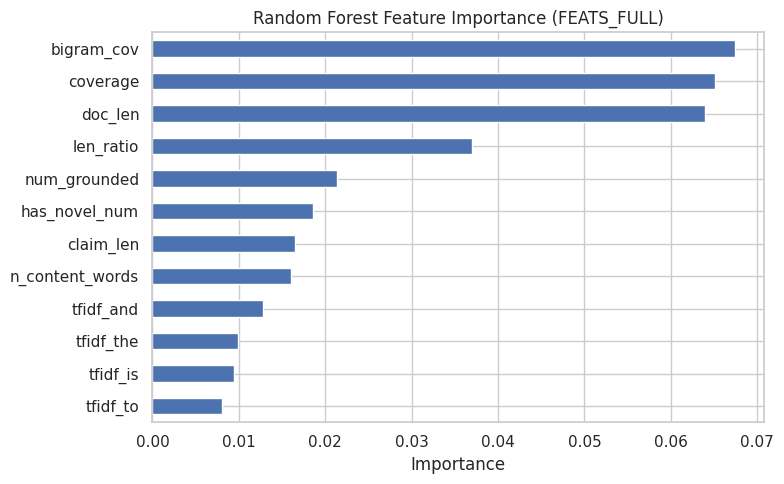

In [ ]:
def top_features(rf, names, k=15):
    imp = pd.Series(rf.feature_importances_, index=names)
    return imp.sort_values(ascending=False).head(k)

print("\nTop features — FEATS_FULL:")
print(top_features(rf_full, names_full).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
top_features(rf_full, names_full, 12).sort_values().plot(
    kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Random Forest Feature Importance (FEATS_FULL)")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 5 — LOCK IN FEATS_SAFE + THRESHOLD TUNING


FINAL MODEL — FEATS_SAFE
                   precision    recall  f1-score   support

Not Supported (0)      0.630     0.573     0.600      1481
    Supported (1)      0.866     0.892     0.879      4603

         accuracy                          0.814      6084
        macro avg      0.748     0.732     0.740      6084
     weighted avg      0.809     0.814     0.811      6084

AUC-ROC: 0.837
Macro F1: 0.740
Minority F1 (class 0): 0.600

Confusion matrix:
[[ 848  633]
 [ 497 4106]]
Default threshold (0.50):
  macro F1:    0.740
  minority F1: 0.600

Best macro F1 threshold:    0.49  →  macro F1 0.740
Best minority F1 threshold: 0.53  →  minority F1 0.603


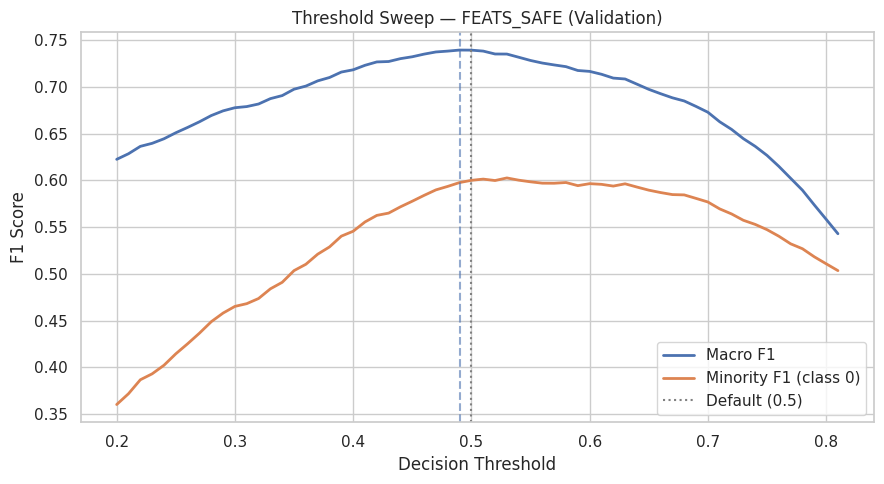


FINAL REPORT @ threshold = 0.49
                   precision    recall  f1-score   support

Not Supported (0)      0.643     0.558     0.598      1481
    Supported (1)      0.864     0.900     0.882      4603

         accuracy                          0.817      6084
        macro avg      0.753     0.729     0.740      6084
     weighted avg      0.810     0.817     0.813      6084

AUC-ROC: 0.837

Per-source: default (0.5) vs tuned threshold
                    n  pct_supported  F1_default  F1_tuned  delta
source                                                           
Wice               70           32.9       0.584     0.570 -0.014
AggreFact-CNN      92           87.0       0.465     0.465  0.000
AggreFact-XSum    156           50.6       0.620     0.612 -0.008
ClaimVerify       218           75.2       0.678     0.673 -0.005
FactCheck-GPT     307           17.3       0.581     0.578 -0.003
TofuEval-MeetB    322           82.0       0.542     0.537 -0.005
Reveal            331

In [ ]:
# ── 3.5.1  TRAIN FINAL MODEL ON FEATS_SAFE ──────────────────
rf_final, proba_val, pred_val_default, names_final = train_eval(
    FEATS_SAFE, "FINAL MODEL — FEATS_SAFE", use_tfidf=True
)


# ── 3.5.2  FIND BEST THRESHOLD FOR MINORITY CLASS ───────────
# Default 0.5 rarely optimal under 3.11x imbalance.
# We sweep thresholds and pick the one that maximizes
# macro F1 on validation (balances both classes fairly).

thresholds = np.arange(0.20, 0.81, 0.01)
macro_f1s, minority_f1s = [], []

for t in thresholds:
    pred_t = (proba_val >= t).astype(int)
    macro_f1s.append(f1_score(y_val, pred_t, average="macro"))
    minority_f1s.append(f1_score(y_val, pred_t, pos_label=0))

macro_f1s   = np.array(macro_f1s)
minority_f1s = np.array(minority_f1s)

best_macro_t    = thresholds[macro_f1s.argmax()]
best_minority_t = thresholds[minority_f1s.argmax()]

print(f"Default threshold (0.50):")
print(f"  macro F1:    {f1_score(y_val, (proba_val>=0.5).astype(int), average='macro'):.3f}")
print(f"  minority F1: {f1_score(y_val, (proba_val>=0.5).astype(int), pos_label=0):.3f}")
print(f"\nBest macro F1 threshold:    {best_macro_t:.2f}  →  macro F1 {macro_f1s.max():.3f}")
print(f"Best minority F1 threshold: {best_minority_t:.2f}  →  minority F1 {minority_f1s.max():.3f}")


# ── 3.5.3  PLOT THRESHOLD SWEEP ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, macro_f1s, label="Macro F1", color="#4C72B0", lw=2)
ax.plot(thresholds, minority_f1s, label="Minority F1 (class 0)", color="#DD8452", lw=2)
ax.axvline(0.5, ls=":", c="gray", label="Default (0.5)")
ax.axvline(best_macro_t, ls="--", c="#4C72B0", alpha=0.6)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("Threshold Sweep — FEATS_SAFE (Validation)")
ax.legend()
plt.tight_layout(); plt.show()


# ── 3.5.4  EVALUATE AT CHOSEN THRESHOLD ─────────────────────
# Going with best_macro_t — balances both classes without
# over-sacrificing the majority. Swap to best_minority_t if
# catching hallucinations matters more than false alarms.
CHOSEN_T = best_macro_t

pred_val_tuned = (proba_val >= CHOSEN_T).astype(int)

print(f"\n{'='*55}")
print(f"FINAL REPORT @ threshold = {CHOSEN_T:.2f}")
print(f"{'='*55}")
print(classification_report(y_val, pred_val_tuned,
      target_names=["Not Supported (0)", "Supported (1)"], digits=3))
print(f"AUC-ROC: {roc_auc_score(y_val, proba_val):.3f}")


# ── 3.5.5  PER-SOURCE AT TUNED THRESHOLD ────────────────────
rows = []
for src in sorted(val_df["dataset"].unique()):
    m = val_df["dataset"] == src
    if m.sum() < 20:
        continue
    _, _, f_def, _ = precision_recall_fscore_support(
        y_val[m], pred_val_default[m], average="macro", zero_division=0)
    _, _, f_tun, _ = precision_recall_fscore_support(
        y_val[m], pred_val_tuned[m], average="macro", zero_division=0)
    rows.append({
        "source": src,
        "n": int(m.sum()),
        "pct_supported": round(y_val[m].mean()*100, 1),
        "F1_default": round(f_def, 3),
        "F1_tuned": round(f_tun, 3),
        "delta": round(f_tun - f_def, 3),
    })

comp_thresh = pd.DataFrame(rows).set_index("source").sort_values("n")
print("\nPer-source: default (0.5) vs tuned threshold")
print(comp_thresh)


# Bias Audit

In [ ]:
# Dataset source Checks
# Check dataset source balance
def check_col_representation(df, col):
  return df[col].value_counts(normalize=True) * 100

def compare_hall_rate_by_source(df, col):
  return df.groupby(col)['label_binary'].mean() * 100

# Check if source groups are represented equally
print(check_col_representation(hall_dec_pd, 'source_ds'))

# Compare average hallucination rate
print(f'\n{compare_hall_rate_by_source(hall_dec_pd, 'source_ds')}')

In [ ]:
# Text length checks
def check_length_bias_by_label(df, length_col):
  print(f"Label bias audit for: {length_col}")

  # Calculate average length for each target label
  label_means = df.groupby('label')[length_col].mean()
  print("Average length per Target Label:")
  print(label_means.round(2))

  # Quantify the gap between PASS and FAIL using the absolute difference between the two classes
  len_gap = abs(label_means['PASS'] - label_means['FAIL'])
  print(f"Gap between PASS and FAIL: {len_gap:.2f} words")

  # Flag if one label has an unfair representation skew (more than a 30% discrepancy)
  baseline_min = label_means.min()
  if len_gap > (baseline_min * 0.3):
      print(f"\nPotential bias: '{length_col}' structurally skews toward one label.")
  else:
      print(f"\nLow bias: '{length_col}' has an equal distribution across both labels.")
  print("-" * 50)
# Run the target label audit for all text length features
check_length_bias_by_label(hall_dec_pd, 'question_len')
check_length_bias_by_label(hall_dec_pd, 'passage_len')
check_length_bias_by_label(hall_dec_pd, 'answer_len')